In [1]:
import itertools
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch.distributions as D
import numpy as np
from numpy.random import default_rng
import pymc as pm
from scipy.stats import vonmises
from scipy.special import i0

from insilico_stimuli.stimuli import GaborSet, CenterSurround

seed = 42
rng = default_rng(seed=seed)
torch.manual_seed(seed=seed)
EPSILON = 1e-12
mpl.style.use("seaborn")
sns.set_palette("colorblind")
sns.set_context("paper")
sns.set_style("darkgrid")
mpl.style.use("seaborn")

/usr/local/lib/python3.8/dist-packages/pkg_resources/__init__.py:123: PkgResourcesDeprecationWarning: 0.23ubuntu1 is an invalid version and will not be supported in a future release
  warnings.warn(
/usr/lib/python3/dist-packages/requests/__init__.py:89: RequestsDependencyWarning: urllib3 (1.26.12) or chardet (3.0.4) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


# Center-surround stimulus method

In [2]:
canvas_size = [50, 50]
location = [25, 25]
orientation_center = np.pi / 2
orientation_surround = 0

In [3]:
np.arange(canvas_size[0])

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49])

In [4]:
x, y = np.meshgrid(
    np.arange(canvas_size[0]) - location[0], np.arange(canvas_size[1]) - location[1]
)

In [5]:
x.shape, y.shape

((50, 50), (50, 50))

In [6]:
x

array([[-25, -24, -23, ...,  22,  23,  24],
       [-25, -24, -23, ...,  22,  23,  24],
       [-25, -24, -23, ...,  22,  23,  24],
       ...,
       [-25, -24, -23, ...,  22,  23,  24],
       [-25, -24, -23, ...,  22,  23,  24],
       [-25, -24, -23, ...,  22,  23,  24]])

In [7]:
y

array([[-25, -25, -25, ..., -25, -25, -25],
       [-24, -24, -24, ..., -24, -24, -24],
       [-23, -23, -23, ..., -23, -23, -23],
       ...,
       [ 22,  22,  22, ...,  22,  22,  22],
       [ 23,  23,  23, ...,  23,  23,  23],
       [ 24,  24,  24, ...,  24,  24,  24]])

In [8]:
R_center = np.array(
    [
        [np.cos(orientation_center), -np.sin(orientation_center)],
        [np.sin(orientation_center), np.cos(orientation_center)],
    ]
)

In [9]:
R_surround = np.array(
    [
        [np.cos(orientation_surround), -np.sin(orientation_surround)],
        [np.sin(orientation_surround), np.cos(orientation_surround)],
    ]
)

In [10]:
coords = np.stack([x.flatten(), y.flatten()])

In [11]:
coords

array([[-25, -24, -23, ...,  22,  23,  24],
       [-25, -25, -25, ...,  24,  24,  24]])

In [12]:
x_center, y_center = R_center.dot(coords)

In [13]:
R_center.shape, coords.shape

((2, 2), (2, 2500))

# ```Stimulus``` method of ```GaborSet(StimulusSet)```

In [94]:
canvas_size = [50, 50]
location = [25, 25]
orientation = np.pi / 2
gamma = 1
size = 25
spatial_frequency = 1 / 20
phase = np.pi / 2
contrast = 2

In [95]:
def gabor_set(
    canvas_size, location, orientation, gamma, size, spatial_frequency, phase, contrast
):

    x, y = np.meshgrid(
        np.arange(canvas_size[0]) - location[0], np.arange(canvas_size[1]) - location[1]
    )
    coords = np.stack([x.flatten(), y.flatten()])
    R_env = np.array(
        [
            [np.cos(-orientation - np.pi / 2), -np.sin(-orientation - np.pi / 2)],
            [np.sin(-orientation - np.pi / 2), np.cos(-orientation - np.pi / 2)],
        ]
    )
    gammas = [1, gamma]
    S_inv = np.diag(1 / np.array(gammas))
    xy = np.stack((x, y), axis=-1)
    envelope = np.exp(
        -0.5 * np.sum(xy @ R_env @ S_inv @ R_env.T * xy, axis=-1) / (size / 4) ** 2
    )
    R = np.array(
        [
            [np.cos(orientation), -np.sin(orientation)],
            [np.sin(orientation), np.cos(orientation)],
        ]
    )
    x, y = R.dot(coords).reshape((2,) + x.shape)
    grating = np.cos(spatial_frequency * (2 * np.pi) * x + phase)
    gabor_no_contrast = grating * envelope
    gabor = contrast * gabor_no_contrast
    return gabor

In [101]:
gabor = gabor_set(
    canvas_size, location, orientation, gamma, size, spatial_frequency, phase, contrast
)

(-0.5, 49.5, 49.5, -0.5)

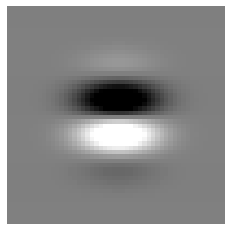

In [102]:
plt.imshow(gabor, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")

In [103]:
def center_surround(
    canvas_size,
    location,
    size_total,
    size_center,
    size_surround,
    contrast_center,
    contrast_surround,
    orientation_center,
    orientation_surround,
    spatial_frequency_center,
    spatial_frequency_surround,
    phase_center,
    phase_surround,
):

    if size_center > size_surround:
        raise ValueError("size_center cannot be larger than size_surround.")

    x, y = np.meshgrid(
        np.arange(canvas_size[0]) - location[0], np.arange(canvas_size[1]) - location[1]
    )

    R_center = np.array(
        [
            [np.cos(orientation_center), -np.sin(orientation_center)],
            [np.sin(orientation_center), np.cos(orientation_center)],
        ]
    )

    R_surround = np.array(
        [
            [np.cos(orientation_surround), -np.sin(orientation_surround)],
            [np.sin(orientation_surround), np.cos(orientation_surround)],
        ]
    )

    coords = np.stack([x.flatten(), y.flatten()])
    x_center, y_center = R_center.dot(coords).reshape((2,) + x.shape)
    x_surround, y_surround = R_surround.dot(coords).reshape((2,) + x.shape)

    norm_xy_center = np.sqrt(x_center**2 + y_center**2)
    norm_xy_surround = np.sqrt(x_surround**2 + y_surround**2)

    envelope_center = norm_xy_center <= size_center * size_total
    envelope_surround = (norm_xy_surround > size_surround * size_total) * (
        norm_xy_surround <= size_total
    )

    grating_center = np.cos(
        spatial_frequency_center * x_center * (2 * np.pi) + phase_center
    )
    grating_surround = np.cos(
        spatial_frequency_surround * x_surround * (2 * np.pi) + phase_surround
    )

    amplitude_center = contrast_center
    amplitude_surround = contrast_surround

    grating_center_contrast = amplitude_center * grating_center
    grating_surround_contrast = amplitude_surround * grating_surround

    return (
        envelope_center * grating_center_contrast
        + envelope_surround * grating_surround_contrast
    )

In [116]:
size_total = 50
size_center = 40 / 4 / 50
size_surround = 40 / 4 / 50
contrast_center = 1
contrast_surround = 1
orientation_center = orientation
orientation_surround = orientation
spatial_frequency_center = spatial_frequency
spatial_frequency_surround = spatial_frequency
phase_center = phase
phase_surround = phase
cs = center_surround(
    canvas_size,
    location,
    size_total,
    size_center,
    size_surround,
    contrast_center,
    contrast_surround,
    orientation_center,
    orientation_surround,
    spatial_frequency_center,
    spatial_frequency_surround,
    phase_center,
    phase_surround,
)

(-0.5, 49.5, 49.5, -0.5)

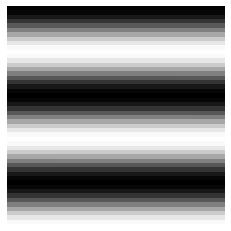

In [117]:
plt.imshow(cs, cmap="gray", vmin=-1, vmax=1)
plt.axis("off")